<a href="https://colab.research.google.com/github/Leo05-u/EMSC2010_GroupProject_1/blob/main/EMSC2010_Group_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Ocean's Eleven Variables

Project week: 5

Project title: Calculating the 95% confidence interval of PO4(ppm) concentration at Heron Island Research Station using Monte Carlo techniques and the bootstrap approach

Datasets used (name and source): Experimental and in situ seawater nutrient data collected as part of a study of pCO2 variability on the reef-building coral Pocillopora damicornis conducted at Heron Island Research Station, Heron Island, southern Great Barrier Reef in 2021 https://www.bco-dmo.org/dataset/885669#data-files

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Leo | Georgie | Yes| Add note|
| Data steward | Georgie | Emily | Yes| Add note|
| Analysis / modelling | Emily | Mel | Yes| Add note|
| Visualisation / interpretation | Mel | Charlotte | Yes| Add note|
| Narrative | Charlotte | Jiah | Yes| Add note|
| Quality Control / Reproducibility  | Jiah | Leo | Yes| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Aim of Ocean's Eleven Varibles week 5 group project:** To use Monte Carlo techniques in order to generate a Bootstrap distribution and a 95% confindence interval calculation of the PO4(ppm) concentration measured at Heron Island Research Station on Heron Island, located in the Southern Great Barrier reef over 2 months.

The reason the bootstrap method was used is because it's key idea is that it simulates the variability someone would expect if they collected a large amount of new PO4 samples at Heron Island Research Station on Heron Island.

The first step of the project was to find the chosen data set and upload it into Colab.

**Dataset selection & cleaning**

Data was found from BCO-DMO; “Experimental and in situ seawater nutrient data collected as part of a study of pCO2 variability on the reef-building coral Pocillopora damicornis conducted at Heron Island Research Station, Heron Island, southern Great Barrier Reef in 2021”. This was downloaded as a csv file, converted to excel, then cleaned by restricting it to measurements taken only on the reef slope, not the flat or any of the experimental values. All other variables were then removed, leaving only an array of 54 measurements of [PO4].

**Citation:** Barott, K., Brown, K. T. (2023). Experimental and in situ seawater nutrient data collected as part of a study of pCO2 variability on the reef-building coral Pocillopora damicornis conducted at Heron Island Research Station, Heron Island, southern Great Barrier Reef in 2021. Biological and Chemical Oceanography Data Management Office (BCO-DMO). (Version 1) Version Date 2022-12-20. doi:10.26008/1912/bco-dmo.885669.1

In [ ]:
#Emily coded data modelling
import pandas as pd
import numpy as np

In [ ]:
spreadsheet_name = 'infieldnutrients.xlsx'
worksheet_name = 'Sheet1'
df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [ ]:
df.head()

,[PO4] (ppm)
0,10.9
1,14.6
2,25.4
3,24.4
4,22.3


The second step was to set up the bootstrap method by randomly reseampling the 54 data points gained from the 'infieldnutrients.xlsx' data set with replacement.

In [ ]:
#PO4 concentration (in ppm) measured on reef slop over 2 months
X = np.array([10.9,14.6,25.4,24.4,22.3,26.2,9.72,9.17,10.6,9.99,11.8,11.4,34.2,18.7,27.8,11.6,10.5,10.4,8.82,8.61,10.3,5.06,4.05,2.78,1.11,2.51,2.39,2.18,2.55,3.26,4.5,3.52,3.66,6.01,6.14,6.15,6.51,5.66,6.35,5.5,5.6,5.12,5.12,4.14,4.57,5.31,5.12,5.4,6.13,4.12,5.51,4.25,5.01,4.22])

In [ ]:
#Randomly resample 54 entries from X 1,000 times with replacement. B will have size (54,1,000)
np.random.seed(42)
B = np.random.choice(X, size=(len(X), 1000), replace=True)

#Define bar as the mean value of each column of B (average PO4 concentration in each random sample). The result should be a single column with 1,000 entries
bar = np.mean(B, axis=0)
print("Bootstrap means created:", bar.shape)

Bootstrap means created: (1000,)


The third step was creating the histogram that would visually represent the bootstrap distribution of mean PO4 concentration at Heron island over 2 months

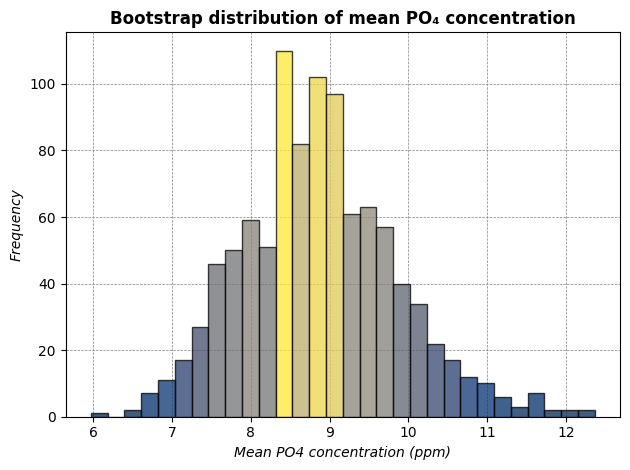

In [ ]:
#Mel coded histogram
#IMPORTING
import matplotlib.pyplot as plt #import graphing library
from matplotlib import colors #for gradient

#HISTOGRAM
fig, ax = plt.subplots(tight_layout=True) #define ax
n, bins, patches = plt.hist(bar, #create histogram
         bins=30, #sqrt of 1000 is around 30, using as bin number
         edgecolor= 'k', #distinguish bins
         alpha=0.75) #see gridlines

#GRADIENT
fracs = n / n.max() #color code by height
norm = colors.Normalize(fracs.min(), fracs.max()) #normalising n for the colourmap scale: 0-1
for thisfrac, thispatch in zip(fracs, patches): #loop objects
    color = plt.cm.cividis(norm(thisfrac)) #colorblind friendly color
    thispatch.set_facecolor(color) #apply color

#GRIDLINES
ax.set_axisbelow(True) #create gridlines
ax.grid(color='gray', linestyle='dashed', linewidth=0.5) #make dashes & gray colour

#LABELS
plt.xlabel("Mean PO4 concentration (ppm)", style='italic') #italicizing the x axis
plt.ylabel("Frequency",  style='italic') #italicizing the y axis
plt.title("Bootstrap distribution of mean PO₄ concentration", fontweight='bold') #bolding the title

#SHOW
plt.show() #show plot

In accordance to what the key idea of the Bootstrap is, this histogram simulates the distribution of mean PO4 concentration an individual would found if they collected new PO4 samples from Heron island.

The forth and final step was calculating the 95% confidence interval and visually displaying the result through CI lines on the exisitng histogram.

The 95% confindence interval is a range of values calculated from sample data where in, if the sampling process was repeated many times, would include the true population parameter 95% of the time.

For this project, the 95% confindence interval was calculated in order to find the range where 95% of all samples will capture the true population parameter.

95% confidence interval: [ 7.11756944 10.93239815]


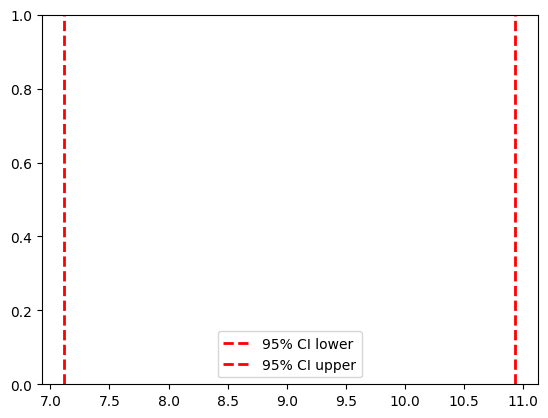

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate confidence interval
ci = np.percentile(bar, [2.5, 97.5])
print("95% confidence interval:", ci)

# Draw CI lines on the existing histogram
plt.axvline(ci[0], color='red', linestyle='dashed', linewidth=2, label='95% CI lower')
plt.axvline(ci[1], color='red', linestyle='dashed', linewidth=2, label='95% CI upper')
plt.legend()
plt.show()

#The phosphate concentrations measured on the reef slope over 2 months, is averaging around 8.75ppm.

The 95% confindence interval for the PO4 concentration measured on the reef slope over 2 months was 7.05043519 - 10.67518981. Therefore, according to the 95% confindence interval, this range is where 95% of all samples will capture the true population parameter.

Week 5 group project reflections:

**Charlotte:** The role I had for the week 5 group project centring on Monte Carlo techniques was role 5, the Narrative Lead. My main responsibilities as the Narrative Lead were to write the markdown explanation in the notebook, ensure logical flow from question to method to results and to summarise key decisions and limitations. In order to complete my role, I focused on writing out the steps of the method we took, explaining our results and ensuring that the notebook flowed correctly. Overall, I had fun being the Narrative Lead and it was a good experience to learn how to apply science report writing in a new medium.


**Jiah:** My role for the week 5 group project on Monte Carlo techniques was Role 6, the Quality Control and Reproducibility Lead. My main responsibilities were to ensure the notebook ran correctly and accurately from top to bottom, check data accessibility, review figures and outputs, and ensure clarity of explanation. To complete this role, I tested the notebook by running all cells sequentially in a particular order, fixed errors and made changes related to execution and variable definitions, and confirmed that the dataset and analysis were consistently precise and had clarity. I also reviewed the figures to ensure they were clearly labelled and accurately identifeid as well as represented the results. Overall, this role helped me understand the importance of reproducibility and organisation in scientific coding, and it was a valuable experience in debugging and improving workflow structure.


**Emily:** My role for this project was analysis/modelling (role 3). To do this role, I uploaded the cleaned dataset into Colab and converted the measurement values into a comma-separated list using the 'textjoin' function in Excel. I then wrote code to randomly resample the data and take an average of each sample, creating a new dataset which could be plotted and interpreted. I found this role enjoyable, and it helped me to further understand the connection between the theory behind bootstrapping and the concrete methods used to get more information from a sample.


**Mel**: My role was role four, the visualisation and interpretation lead, for our project on Monte Carlo techniques. This meant that I was in charge of  producing any figures and plots as needed to our project; with specifics including labelling if the axes, choice of units, and making sure the figures were visually distinct, and understandable to all. To achieve these requirements, I bolded the title, italicised the Y and X axes, to differentiate them, used a colourblind friendly gradient to highlight mean concentration, and used to graph to make an inference as to our aim. This role was useful in expanding my knowledge of figure colour, where I learned to code gradients.

Leo: My role for the week 5 group project centring on Monte Carlo techniques was role 1, Github & integration. My role was to create the colab workbook and ensure it could be used by all members of the group, as well as fill in the project overview and the Roles & contributions table. I was incharge of ensuring the data set was available in the Github repository and accessible for the workbook. My other duty is submission of the workbook with meaningful commits upon commiting the workbook to Github.

**Georgie:** My role for the week 5 group project was role 2; data steward. This involved locating, loading, and inspecting the dataset, performing basic data cleaning and quality control, and documenting how the data has been obtained & cleaned. Finding data that was able to be downloaded in an easily useable format was difficult, however once suitable data was found, the cleaning process was very straightforward.